# 05 — Speech Recognition (ASR)

Dans ce notebook, nous allons construire un premier pipeline de reconnaissance vocale automatique.

L’objectif est de comprendre comment passer d’un signal audio contenant de la parole à une transcription textuelle.

Nous allons suivre ce pipeline :

```text
Audio
→ modèle ASR
→ tokens
→ décodage
→ transcription
→ normalisation
→ Word Error Rate

## Objectifs du notebook

À la fin de ce notebook, nous saurons :

- comprendre le rôle du token blank dans CTC ;
- implémenter un greedy decoder ;
- transformer une séquence de tokens CTC en texte ;
- comprendre substitutions, suppressions et insertions ;
- calculer le Word Error Rate ;
- charger un vrai fichier vocal ;
- transcrire un audio avec un modèle ASR préentraîné ;
- comparer une transcription prédite à une transcription de référence ;
- analyser les erreurs de reconnaissance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

from pathlib import Path

## 1. Comprendre le décodage CTC

Un modèle CTC produit un token pour chaque frame temporelle.

Comme l’audio contient beaucoup plus de frames que le texte final contient de caractères, plusieurs frames peuvent prédire le même token.

CTC utilise aussi un token spécial appelé `blank`, qui signifie qu’aucun caractère n’est émis à cette frame.

Pour obtenir la transcription finale, on applique deux opérations :

1. supprimer les répétitions consécutives ;
2. supprimer les tokens `blank`.

In [5]:
ctc_tokens = [
    "_", "h", "h", "_",
    "e", "_",
    "l", "_", "l", "_",
    "o", "_"
]

print("Séquence brute :", ctc_tokens)

Séquence brute : ['_', 'h', 'h', '_', 'e', '_', 'l', '_', 'l', '_', 'o', '_']


## 2. Implémentation d’un greedy decoder CTC

Le greedy decoder sélectionne le token le plus probable à chaque frame.

Une fois la séquence obtenue, nous devons :

1. supprimer les répétitions consécutives ;
2. supprimer les tokens `blank`.

Nous allons commencer par écrire cette logique manuellement sur une séquence déjà prédite.

In [6]:
def ctc_greedy_decode(tokens, blank_token="_"):
    decoded_tokens = []
    previous_token = None

    for token in tokens:
        if token != previous_token:
            if token != blank_token:
                decoded_tokens.append(token)

        previous_token = token

    return "".join(decoded_tokens)

In [7]:
decoded_text = ctc_greedy_decode(ctc_tokens)

print("Séquence brute :", ctc_tokens)
print("Texte décodé :", decoded_text)

Séquence brute : ['_', 'h', 'h', '_', 'e', '_', 'l', '_', 'l', '_', 'o', '_']
Texte décodé : hello


## 3. Cas particuliers du décodage CTC

Le comportement de CTC dépend fortement de la position des tokens `blank`.

Deux lettres identiques consécutives sans blank sont fusionnées.

En revanche, si un blank les sépare, elles restent distinctes.

In [8]:
examples = {
    "aa sans blank": ["a", "a"],
    "aa avec blank": ["a", "_", "a"],
    "hello": ["_", "h", "h", "_", "e", "_", "l", "_", "l", "_", "o", "_"],
    "book": ["b", "_", "o", "_", "o", "_", "k"]
}

for name, tokens in examples.items():
    decoded = ctc_greedy_decode(tokens)
    print(f"{name:15s} -> {decoded}")

aa sans blank   -> a
aa avec blank   -> aa
hello           -> hello
book            -> book


## 4. Word Error Rate (WER)

Le WER mesure la différence entre une transcription de référence et une transcription prédite.

Il prend en compte trois types d’erreurs :

- substitution : un mot est remplacé par un autre ;
- suppression : un mot attendu manque ;
- insertion : un mot supplémentaire apparaît.

La formule est :

```text
WER = (S + D + I) / N

où :
S = substitutions ;
D = suppressions ;
I = insertions ;
N = nombre de mots dans la transcription de référence.
Pour calculer ces erreurs, nous allons utiliser une matrice de programmation dynamique basée sur la distance d’édition de Levenshtein.

In [9]:
def word_error_rate(reference, hypothesis):
    ref_words = reference.split()
    hyp_words = hypothesis.split()

    n = len(ref_words)
    m = len(hyp_words)

    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(n + 1):
        dp[i, 0] = i

    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            if ref_words[i - 1] == hyp_words[j - 1]:
                dp[i, j] = dp[i - 1, j - 1]

            else:
                substitution = dp[i - 1, j - 1] + 1
                deletion = dp[i - 1, j] + 1
                insertion = dp[i, j - 1] + 1

                dp[i, j] = min(
                    substitution,
                    deletion,
                    insertion
                )

    wer = dp[n, m] / max(n, 1)

    return wer

In [10]:
reference = "the weather is sunny today"
hypothesis = "the weather was sunny"

wer = word_error_rate(
    reference,
    hypothesis
)

print(f"WER : {wer:.2%}")

WER : 40.00%


## 5. Comprendre les trois types d’erreurs

Le WER regroupe trois types d’erreurs :

- substitution : un mot est remplacé par un autre ;
- suppression : un mot de référence manque dans la prédiction ;
- insertion : un mot supplémentaire apparaît dans la prédiction.

Nous allons tester chaque cas séparément.

In [11]:
test_cases = {
    "substitution": (
        "the weather is sunny",
        "the weather was sunny"
    ),
    "deletion": (
        "the weather is sunny",
        "the weather sunny"
    ),
    "insertion": (
        "the weather is sunny",
        "the weather is very sunny"
    )
}

for error_type, (reference, hypothesis) in test_cases.items():
    wer = word_error_rate(reference, hypothesis)

    print(f"{error_type:12s} -> WER : {wer:.2%}")

substitution -> WER : 25.00%
deletion     -> WER : 25.00%
insertion    -> WER : 25.00%


## 6. Normalisation du texte

Deux transcriptions peuvent avoir le même contenu tout en étant écrites différemment.

Exemple :

```text
Référence : "Hello, World!"
Prédiction : "hello world"

In [41]:
import re
import string

def normalize_text(text):
    text = text.lower()

    # Uniformiser les apostrophes typographiques
    text = text.replace("’", "'")

    # Supprimer la ponctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Supprimer les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [42]:
reference = "Hello, World!"
hypothesis = "hello world"

reference_normalized = normalize_text(reference)
hypothesis_normalized = normalize_text(hypothesis)

print("Référence normalisée :", reference_normalized)
print("Prédiction normalisée :", hypothesis_normalized)

print(
    "WER après normalisation :",
    f"{word_error_rate(reference_normalized, hypothesis_normalized):.2%}"
)

Référence normalisée : hello world
Prédiction normalisée : hello world
WER après normalisation : 0.00%


## 7. Chargement d’un vrai fichier vocal

Nous allons maintenant passer d’exemples théoriques à un véritable signal de parole.

Nous réutilisons un extrait vocal déjà présent dans le projet.

Avant d’utiliser un modèle ASR, nous allons vérifier :

- que le fichier existe ;
- son sample rate ;
- sa durée ;
- sa forme.

In [43]:
audio_path = Path("audio_samples/voice_excerpt.wav")

print("Fichier trouvé :", audio_path.exists())

speech_audio, speech_sample_rate = librosa.load(
    audio_path,
    sr=None,
    mono=True
)

speech_duration = len(speech_audio) / speech_sample_rate

print("Sample rate :", speech_sample_rate, "Hz")
print("Shape :", speech_audio.shape)
print(f"Durée : {speech_duration:.2f} secondes")

Fichier trouvé : True
Sample rate : 44100 Hz
Shape : (36823040,)
Durée : 834.99 secondes


## 8. Sélection d’un court extrait vocal

Le fichier source dure environ 835 secondes.

Pour notre premier test ASR, nous allons travailler sur un court extrait de 15 secondes.

Cela permet :

- de réduire le temps d’inférence ;
- de faciliter l’écoute de la transcription ;
- de comparer facilement la prédiction avec le contenu réellement prononcé.

In [44]:
start_time = 20
excerpt_duration = 19

start_sample = int(
    start_time * speech_sample_rate
)

end_sample = int(
    (start_time + excerpt_duration)
    * speech_sample_rate
)

speech_excerpt = speech_audio[
    start_sample:end_sample
]

print("Shape de l'extrait :", speech_excerpt.shape)

print(
    "Durée :",
    len(speech_excerpt) / speech_sample_rate,
    "secondes"
)

Shape de l'extrait : (837900,)
Durée : 19.0 secondes


In [45]:
from IPython.display import Audio, display

## 9. Écoute et visualisation de l’extrait

Avant la transcription automatique, nous allons écouter l’extrait choisi et visualiser sa waveform.

Cela nous permettra de vérifier qu’il contient bien de la parole exploitable.

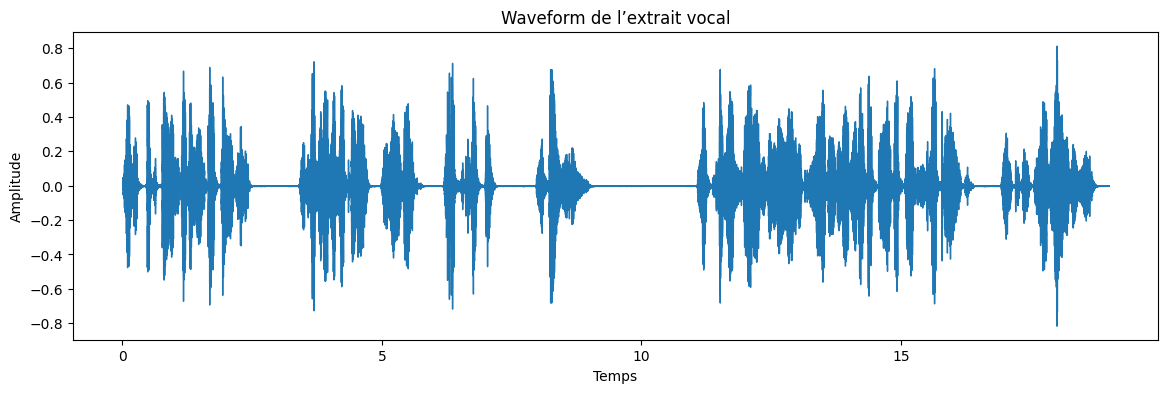

In [46]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    speech_excerpt,
    sr=speech_sample_rate
)

plt.title("Waveform de l’extrait vocal")
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.show()

In [47]:
display(
    Audio(
        speech_excerpt,
        rate=speech_sample_rate
    )
)

## 10. Rééchantillonnage à 16 kHz

La plupart des modèles ASR préentraînés utilisent un audio mono à 16 kHz.

Nous allons donc convertir notre extrait de 44,1 kHz vers 16 kHz avant l’inférence.

In [48]:
asr_sample_rate = 16000

speech_excerpt_16k = librosa.resample(
    speech_excerpt,
    orig_sr=speech_sample_rate,
    target_sr=asr_sample_rate
)

print("Sample rate original :", speech_sample_rate, "Hz")
print("Sample rate ASR :", asr_sample_rate, "Hz")
print("Échantillons avant :", len(speech_excerpt))
print("Échantillons après :", len(speech_excerpt_16k))
print(
    "Durée après :",
    len(speech_excerpt_16k) / asr_sample_rate,
    "secondes"
)

Sample rate original : 44100 Hz
Sample rate ASR : 16000 Hz
Échantillons avant : 837900
Échantillons après : 304000
Durée après : 19.0 secondes


## 11. Chargement d’un modèle ASR préentraîné

Nous allons maintenant utiliser un modèle de reconnaissance vocale préentraîné.

L’objectif n’est pas encore de fine-tuner Whisper, mais simplement de construire un pipeline complet :

```text
audio 16 kHz
→ modèle ASR
→ transcription texte
→ comparaison avec une référence
→ WER

In [49]:
from transformers import pipeline

## 12. Création du pipeline ASR

Nous allons utiliser un modèle Whisper préentraîné via Hugging Face Transformers.

Le pipeline va :

- recevoir notre extrait audio à 16 kHz ;
- extraire automatiquement les features nécessaires ;
- exécuter le modèle ;
- décoder les tokens produits ;
- retourner la transcription.

In [50]:
asr_pipeline = pipeline(
    task="automatic-speech-recognition",
    model="openai/whisper-tiny"
)

print("Pipeline ASR chargé")

Device set to use mps:0


Pipeline ASR chargé


## 13. Transcription automatique

Nous allons maintenant envoyer l’extrait audio rééchantillonné à 16 kHz dans le pipeline ASR.

Le modèle retournera une première transcription automatique.

In [51]:
result = asr_pipeline(
    {
        "array": speech_excerpt_16k,
        "sampling_rate": asr_sample_rate
    },
    generate_kwargs={
        "task": "transcribe"
    }
)

predicted_text = result["text"]

print("Transcription prédite :")
print(predicted_text)

Transcription prédite :
 durant octobre 2014, et forseur le blocus, le julverne, chapitre 1, le Delphine. Le premier fleuve dont les oséquumères sous les roues d'un bateau à vapeur fut la Clyde, c'était en 1812.


## 14. Transcription de référence

Pour évaluer le modèle, nous devons disposer d’une transcription correcte de l’extrait audio.

Cette transcription servira de référence, tandis que la sortie de Whisper sera considérée comme l’hypothèse prédite.

Nous pourrons ensuite normaliser les deux textes et calculer le Word Error Rate.

In [52]:
reference_text = """
Durant Octobre 2014, Les Forceurs de blocus de Jules Verne, chapitre 1, Le Delphin
Le premier fleuve dont les eaux écumèrent sous les roues d’un bateau à vapeur fut la Clyde. C’était en 1812
"""

print(reference_text)


Durant Octobre 2014, Les Forceurs de blocus de Jules Verne, chapitre 1, Le Delphin
Le premier fleuve dont les eaux écumèrent sous les roues d’un bateau à vapeur fut la Clyde. C’était en 1812



In [53]:
reference_normalized = normalize_text(reference_text)
prediction_normalized = normalize_text(predicted_text)

print("Référence normalisée :")
print(reference_normalized)

print("\nPrédiction normalisée :")
print(prediction_normalized)

Référence normalisée :
durant octobre 2014 les forceurs de blocus de jules verne chapitre 1 le delphin le premier fleuve dont les eaux écumèrent sous les roues dun bateau à vapeur fut la clyde cétait en 1812

Prédiction normalisée :
durant octobre 2014 et forseur le blocus le julverne chapitre 1 le delphine le premier fleuve dont les oséquumères sous les roues dun bateau à vapeur fut la clyde cétait en 1812


In [54]:
wer = word_error_rate(
    reference_normalized,
    prediction_normalized
)

print(f"WER : {wer:.2%}")

WER : 26.47%


## 15. Résultat et interprétation

Le modèle Whisper Tiny obtient un Word Error Rate de **26,47 %** sur cet extrait.

Cela signifie qu’environ un mot sur quatre contient une erreur de reconnaissance, une suppression ou une insertion.

Les principales difficultés observées concernent :

- les noms propres, comme *Jules Verne* et *Le Delphin* ;
- certains mots rares ou littéraires, comme *écumèrent* ;
- quelques confusions phonétiques entre des mots proches.

Malgré ces erreurs, le modèle reconnaît correctement une grande partie de la phrase et conserve globalement le sens du passage.

Cette expérience montre également pourquoi le WER doit être calculé après une normalisation cohérente du texte de référence et de la transcription prédite.

## 16. Analyse détaillée des erreurs

Le WER donne un score global, mais il ne montre pas directement quelles erreurs ont été commises.

Nous allons donc aligner la transcription de référence et la prédiction afin d’identifier :

- les substitutions ;
- les suppressions ;
- les insertions.

In [55]:
def align_words(reference, hypothesis):
    ref_words = reference.split()
    hyp_words = hypothesis.split()

    n = len(ref_words)
    m = len(hyp_words)

    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(n + 1):
        dp[i, 0] = i

    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            if ref_words[i - 1] == hyp_words[j - 1]:
                dp[i, j] = dp[i - 1, j - 1]

            else:
                substitution = dp[i - 1, j - 1] + 1
                deletion = dp[i - 1, j] + 1
                insertion = dp[i, j - 1] + 1

                dp[i, j] = min(
                    substitution,
                    deletion,
                    insertion
                )

    return dp

In [56]:
alignment_matrix = align_words(
    reference_normalized,
    prediction_normalized
)

print("Shape :", alignment_matrix.shape)
print("Distance minimale :", alignment_matrix[-1, -1])

Shape : (35, 33)
Distance minimale : 9


In [57]:
def get_word_errors(reference, hypothesis, dp):
    ref_words = reference.split()
    hyp_words = hypothesis.split()

    i = len(ref_words)
    j = len(hyp_words)

    errors = []

    while i > 0 or j > 0:

        # Mot correct
        if (
            i > 0
            and j > 0
            and ref_words[i - 1] == hyp_words[j - 1]
        ):
            i -= 1
            j -= 1

        # Substitution
        elif (
            i > 0
            and j > 0
            and dp[i, j] == dp[i - 1, j - 1] + 1
        ):
            errors.append(
                (
                    "SUBSTITUTION",
                    ref_words[i - 1],
                    hyp_words[j - 1]
                )
            )
            i -= 1
            j -= 1

        # Suppression
        elif (
            i > 0
            and dp[i, j] == dp[i - 1, j] + 1
        ):
            errors.append(
                (
                    "DELETION",
                    ref_words[i - 1],
                    "-"
                )
            )
            i -= 1

        # Insertion
        else:
            errors.append(
                (
                    "INSERTION",
                    "-",
                    hyp_words[j - 1]
                )
            )
            j -= 1

    errors.reverse()

    return errors

In [58]:
errors = get_word_errors(
    reference_normalized,
    prediction_normalized,
    alignment_matrix
)

for error_type, reference_word, predicted_word in errors:
    print(
        f"{error_type:12s} | "
        f"{reference_word:15s} -> {predicted_word}"
    )

SUBSTITUTION | les             -> et
SUBSTITUTION | forceurs        -> forseur
SUBSTITUTION | de              -> le
DELETION     | de              -> -
SUBSTITUTION | jules           -> le
SUBSTITUTION | verne           -> julverne
SUBSTITUTION | delphin         -> delphine
DELETION     | eaux            -> -
SUBSTITUTION | écumèrent       -> oséquumères


In [59]:
from collections import Counter

error_counts = Counter(
    error_type for error_type, _, _ in errors
)

print("Nombre total d'erreurs :", len(errors))
print("Substitutions :", error_counts["SUBSTITUTION"])
print("Suppressions :", error_counts["DELETION"])
print("Insertions :", error_counts["INSERTION"])

Nombre total d'erreurs : 9
Substitutions : 7
Suppressions : 2
Insertions : 0


## 17. Visualisation des erreurs ASR

Nous allons représenter la répartition des erreurs détectées par le WER.

Cela permet de voir rapidement si le modèle fait surtout des substitutions, des suppressions ou des insertions.

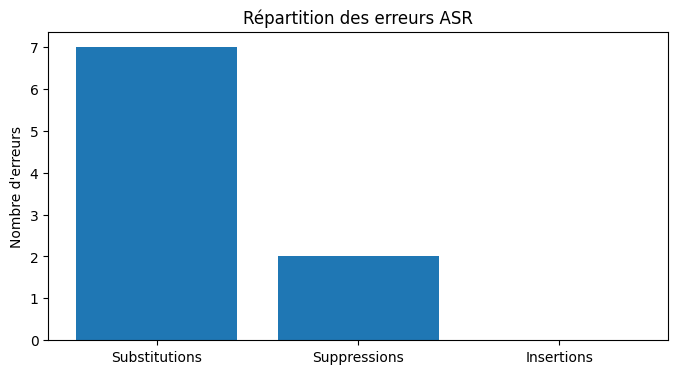

In [60]:
error_labels = [
    "Substitutions",
    "Suppressions",
    "Insertions"
]

error_values = [
    error_counts["SUBSTITUTION"],
    error_counts["DELETION"],
    error_counts["INSERTION"]
]

plt.figure(figsize=(8, 4))
plt.bar(error_labels, error_values)

plt.title("Répartition des erreurs ASR")
plt.ylabel("Nombre d'erreurs")
plt.show()

In [61]:
import pandas as pd

errors_df = pd.DataFrame(
    errors,
    columns=[
        "Type d'erreur",
        "Référence",
        "Prédiction"
    ]
)

errors_df

,Type d'erreur,Référence,Prédiction
0,SUBSTITUTION,les,et
1,SUBSTITUTION,forceurs,forseur
2,SUBSTITUTION,de,le
3,DELETION,de,-
4,SUBSTITUTION,jules,le
5,SUBSTITUTION,verne,julverne
6,SUBSTITUTION,delphin,delphine
7,DELETION,eaux,-
8,SUBSTITUTION,écumèrent,oséquumères


In [ ]:
## 18. Conclusion

Dans ce notebook, nous avons construit un pipeline complet de reconnaissance automatique de la parole.

Nous avons appris à :

- comprendre le principe du décodage CTC ;
- utiliser le blank token et le greedy decoding ;
- calculer le Word Error Rate (WER) ;
- normaliser correctement une transcription avant l’évaluation ;
- préparer un extrait audio à 16 kHz ;
- utiliser un modèle ASR préentraîné avec Whisper Tiny ;
- comparer une transcription prédite à une transcription de référence ;
- identifier les substitutions, suppressions et insertions ;
- analyser et visualiser les erreurs de reconnaissance.

Sur notre extrait de 19 secondes, Whisper Tiny a obtenu un **WER de 26,47 %**, avec :

- **7 substitutions** ;
- **2 suppressions** ;
- **0 insertion**.

Les erreurs observées concernent principalement les noms propres, les mots rares et certaines séquences phonétiquement ambiguës.

Ce notebook montre qu'un système ASR ne doit pas être évalué uniquement à partir de sa transcription visuelle : des métriques comme le WER et une analyse détaillée des erreurs permettent de mesurer beaucoup plus précisément ses performances.

### Pipeline final

```text
Audio
→ sélection de l'extrait
→ rééchantillonnage à 16 kHz
→ modèle ASR
→ transcription
→ normalisation
→ alignement référence/prédiction
→ WER
→ analyse des erreurs